### Step: Data Cleaning and Exploratory Analysis

Cleaned Dataset Info
Total Calls After Cleaning: 4054
Call Time Range: 2021-01-01 09:12:58 to 2021-03-31 17:02:24

Topic Distribution:
 Topic
Streaming            847
Payment related      818
Technical Support    805
Admin Support        795
Contract related     789
Name: count, dtype: int64

Resolved Status:
 Resolved
Y    3646
N     408
Name: count, dtype: int64


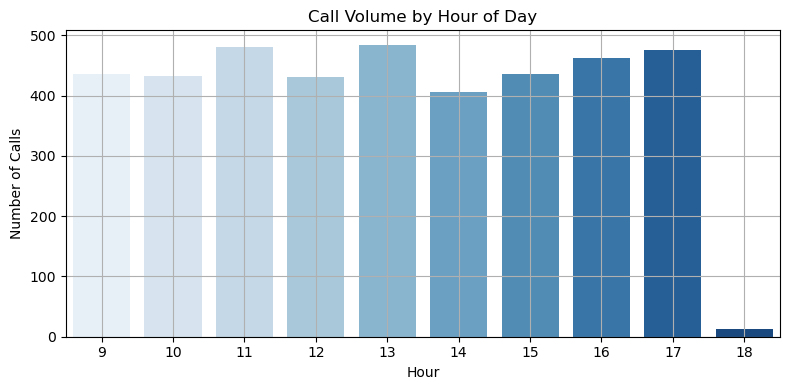

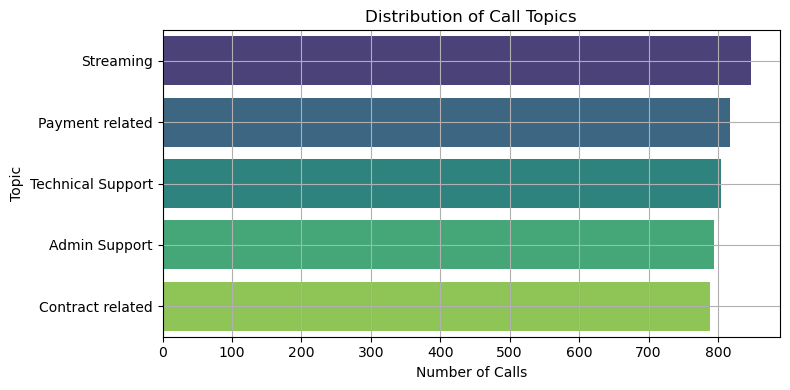

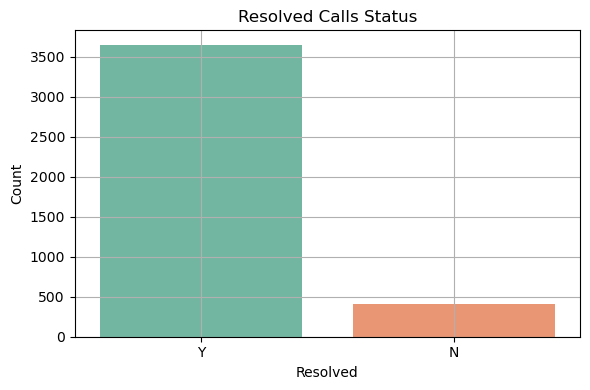


Cleaned Data Preview:
             Timestamp              Topic  DurationSec
0 2021-01-01 09:12:58   Contract related        143.0
1 2021-01-01 09:12:58  Technical Support        242.0
2 2021-01-01 09:47:31   Contract related        131.0
3 2021-01-01 09:47:31   Contract related         37.0
4 2021-01-01 10:00:29    Payment related         60.0


In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_excel(r"C:\Users\Hazim\Desktop\Research_project_B\ModifiedCallCenterTwo.xlsx", sheet_name="Sheet1")

# Create a timestamp from Date and Time columns
df['Timestamp'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str))

# Keep only answered calls
df = df[df['Answered (Y/N)'] == 'Y'].copy()

# Convert talk duration to seconds
df['ServiceTime'] = pd.to_timedelta(df['AvgTalkDuration'], errors='coerce').dt.total_seconds()

# Remove rows with missing values
df_clean = df.dropna(subset=['Timestamp', 'ServiceTime'])

# Sort by time to keep order
df_clean = df_clean.sort_values('Timestamp').reset_index(drop=True)

# Show basic info about the dataset
print("Cleaned Dataset Info")
print(f"Total Calls After Cleaning: {len(df_clean)}")
print(f"Call Time Range: {df_clean['Timestamp'].min()} to {df_clean['Timestamp'].max()}")
print("\nTopic Distribution:\n", df_clean['Topic'].value_counts())
print("\nResolved Status:\n", df_clean['Resolved'].value_counts())

# Plot number of calls by hour
df_clean['Hour'] = df_clean['Timestamp'].dt.hour
plt.figure(figsize=(8, 4))
sns.countplot(x='Hour', data=df_clean, palette="Blues")
plt.title("Call Volume by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Calls")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot distribution of topics
plt.figure(figsize=(8, 4))
sns.countplot(y='Topic', data=df_clean, order=df_clean['Topic'].value_counts().index, palette="viridis")
plt.title("Distribution of Call Topics")
plt.xlabel("Number of Calls")
plt.ylabel("Topic")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot resolution status
plt.figure(figsize=(6, 4))
sns.countplot(x='Resolved', data=df_clean, palette="Set2")
plt.title("Resolved Calls Status")
plt.xlabel("Resolved")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

# Keep only the needed columns and rename one
df_clean = df_clean[['Timestamp', 'Topic', 'ServiceTime']].copy()
df_clean = df_clean.rename(columns={"ServiceTime": "DurationSec"})

# Show first few cleaned rows
print("\nCleaned Data Preview:\n", df_clean.head())


In this step, we import and clean our call center dataset. We combine timestamps, remove unanswered calls, and convert talk durations into seconds for easier modeling. We also explore basic distributions like call volume by hour and topic using count plots. This sets up a clean and structured dataset for simulation and modeling in later steps.

### Assumption Validation using Statistical Tests

Hypothesis Test 1: Interarrival Times ~ Exponential
H0: Interarrival times follow an Exponential distribution
H1: Interarrival times do NOT follow an Exponential distribution
KS Statistic = 0.3410
P-Value = 0.0000
Result: Reject H0 → Interarrival times are NOT Exponentially distributed

Hypothesis Test 2: Service Times ~ Exponential
H0: Service times follow an Exponential distribution
H1: Service times do NOT follow an Exponential distribution
KS Statistic = 0.1933
P-Value = 0.0000
Result: Reject H0 → Service times are NOT Exponentially distributed


c:\Users\Hazim\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Hazim\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


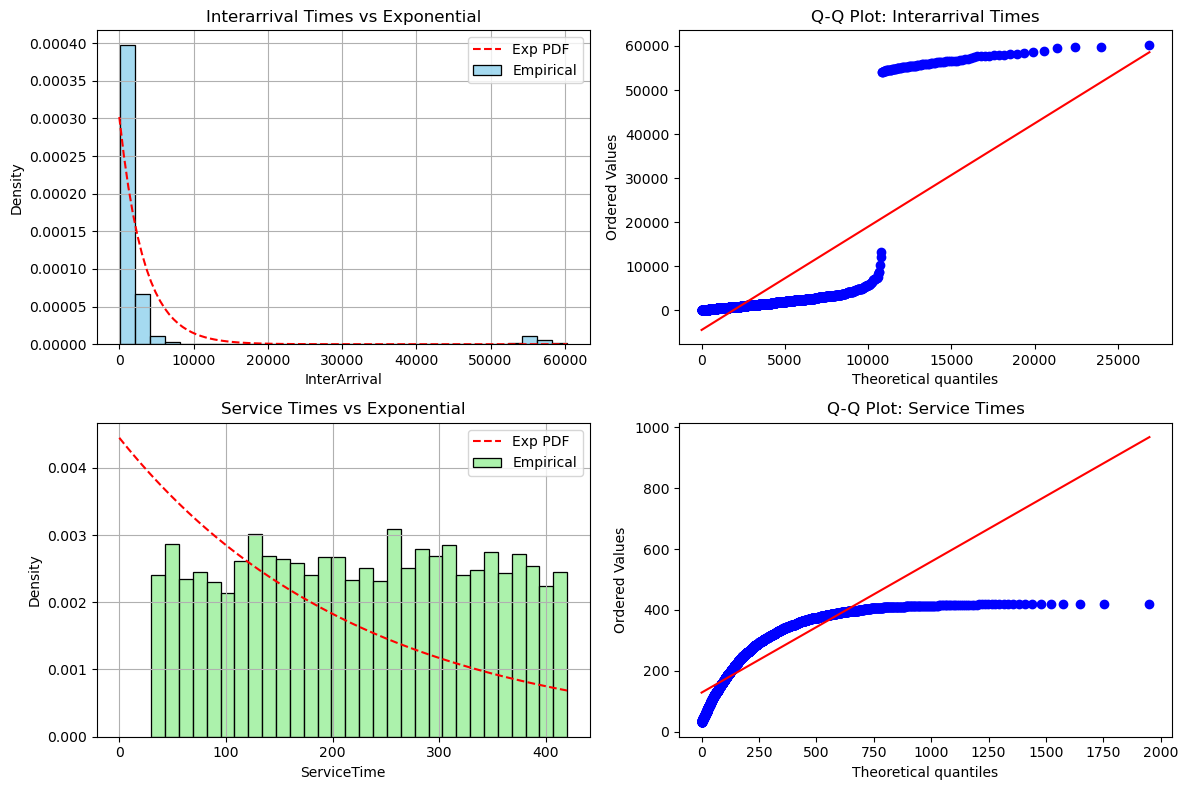

In [74]:
from scipy.stats import kstest, expon, probplot
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate time between each call
df['InterArrival'] = df['Timestamp'].diff().dt.total_seconds()

# Remove invalid interarrival and service times
inter_arrivals = df['InterArrival'].dropna()
inter_arrivals = inter_arrivals[inter_arrivals > 0]

service_times = df['ServiceTime']
service_times = service_times[service_times > 0]

# KS Test: Are interarrival times exponential?
print("Hypothesis Test 1: Interarrival Times ~ Exponential")
print("H0: Interarrival times follow an Exponential distribution")
print("H1: Interarrival times do NOT follow an Exponential distribution")

mean_interarrival = inter_arrivals.mean()
ks_stat_ia, p_val_ia = kstest(inter_arrivals, 'expon', args=(0, mean_interarrival))

print(f"KS Statistic = {ks_stat_ia:.4f}")
print(f"P-Value = {p_val_ia:.4f}")
if p_val_ia < 0.05:
    print("Result: Reject H0 → Interarrival times are NOT Exponentially distributed")
else:
    print("Result: Fail to reject H0 → Interarrival assumption seems okay")

# KS Test: Are service times exponential?
print("\nHypothesis Test 2: Service Times ~ Exponential")
print("H0: Service times follow an Exponential distribution")
print("H1: Service times do NOT follow an Exponential distribution")

mean_service = service_times.mean()
ks_stat_st, p_val_st = kstest(service_times, 'expon', args=(0, mean_service))

print(f"KS Statistic = {ks_stat_st:.4f}")
print(f"P-Value = {p_val_st:.4f}")
if p_val_st < 0.05:
    print("Result: Reject H0 → Service times are NOT Exponentially distributed")
else:
    print("Result: Fail to reject H0 → Service time assumption seems okay")

# Visualize histograms and Q-Q plots
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Interarrival histogram and fitted PDF
sns.histplot(inter_arrivals, bins=30, stat="density", ax=axs[0, 0], color='skyblue', label='Empirical')
x = np.linspace(0, inter_arrivals.max(), 100)
axs[0, 0].plot(x, expon.pdf(x, scale=mean_interarrival), 'r--', label='Exp PDF')
axs[0, 0].set_title("Interarrival Times vs Exponential")
axs[0, 0].legend()
axs[0, 0].grid(True)

# Q-Q Plot for Interarrivals
probplot(inter_arrivals, dist="expon", sparams=(0, mean_interarrival), plot=axs[0, 1])
axs[0, 1].set_title("Q-Q Plot: Interarrival Times")

# Service time histogram and fitted PDF
sns.histplot(service_times, bins=30, stat="density", ax=axs[1, 0], color='lightgreen', label='Empirical')
x = np.linspace(0, service_times.max(), 100)
axs[1, 0].plot(x, expon.pdf(x, scale=mean_service), 'r--', label='Exp PDF')
axs[1, 0].set_title("Service Times vs Exponential")
axs[1, 0].legend()
axs[1, 0].grid(True)

# Q-Q Plot for Service Times
probplot(service_times, dist="expon", sparams=(0, mean_service), plot=axs[1, 1])
axs[1, 1].set_title("Q-Q Plot: Service Times")

plt.tight_layout()
plt.show()


We tested if interarrival and service times follow an exponential distribution using the KS test:

Interarrival Times: KS = 0.3410, P = 0.0000 → Not exponential
Service Times: KS = 0.1933, P = 0.0000 →  Not exponential.

the Q-Q plots and histograms also show these patterns clearly.

Since both assumptions are invalid, we avoid classic queue models (like M/M/1) and use PPO, a reinforcement learning method that learns directly from real data without such assumptions.

### First-Come-First-Serve (FCFS) Simulation (MDP Baseline)

In [ ]:
import numpy as np
import random
from datetime import timedelta
import matplotlib.pyplot as plt

# Calculate time gaps between calls
df_clean['InterArrival'] = df_clean['Timestamp'].diff().dt.total_seconds()
df_clean = df_clean.dropna(subset=['InterArrival']).reset_index(drop=True)
df_clean = df_clean[df_clean['InterArrival'] > 0]

# Simulate serving calls in arrival order (FCFS)
waiting_times = []
fcfs_waits = []
server_busy_until = df_clean['Timestamp'].iloc[0]

for i in range(len(df_clean)):
    arrival_time = df_clean['Timestamp'].iloc[i]
    service_time = df_clean['DurationSec'].iloc[i]

    # Choose the later time: arrival or server availability
    start_time = max(arrival_time, server_busy_until)

    # Update server status and calculate wait time
    end_time = start_time + timedelta(seconds=service_time)
    server_busy_until = end_time
    wait_time = (start_time - arrival_time).total_seconds()

    waiting_times.append(wait_time)
    fcfs_waits.append(wait_time)

print("MDP (FCFS) Simulation Completed.")


MDP (FCFS) Simulation Completed.


### Q-learning Simulation on Real Call Center Data
In this section, we apply Q-learning to a real-world call center dataset.
The model learns to assign incoming calls from two queues (Q1 and Q2) to two servers by optimizing decisions through rewards and penalties.
We record performance metrics like average queue lengths, server utilization, and average customer waiting time to evaluate how well the agent learns over 100 episodes.

Episode 0 - Total reward: -450978.60, Epsilon: 0.050
  Q1 Avg: 189.30, Q2 Avg: 957.24
Episode 10 - Total reward: -617351.00, Epsilon: 0.050
  Q1 Avg: 600.68, Q2 Avg: 811.06
Episode 20 - Total reward: -594305.60, Epsilon: 0.050
  Q1 Avg: 761.02, Q2 Avg: 616.46
Episode 30 - Total reward: -606506.00, Epsilon: 0.050
  Q1 Avg: 620.38, Q2 Avg: 771.64
Episode 40 - Total reward: -640764.40, Epsilon: 0.050
  Q1 Avg: 156.88, Q2 Avg: 1281.14
Episode 50 - Total reward: -681615.60, Epsilon: 0.050
  Q1 Avg: 78.90, Q2 Avg: 1493.98
Episode 60 - Total reward: -658519.40, Epsilon: 0.050
  Q1 Avg: 153.68, Q2 Avg: 1331.38
Episode 70 - Total reward: -584811.40, Epsilon: 0.050
  Q1 Avg: 189.90, Q2 Avg: 1190.58
Episode 80 - Total reward: -618541.80, Epsilon: 0.050
  Q1 Avg: 680.96, Q2 Avg: 737.84
Episode 90 - Total reward: -603165.00, Epsilon: 0.050
  Q1 Avg: 59.70, Q2 Avg: 1361.20


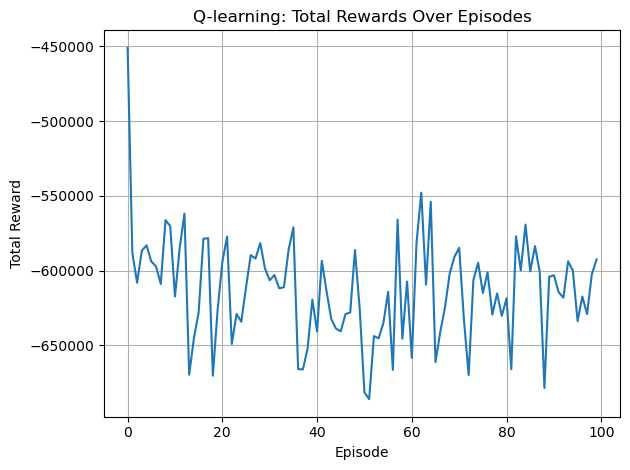

Q-learning Average Waiting Time: 1366194.37 seconds


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

# Step 1: Prepare data
df['Timestamp'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str))
df = df[df['Answered (Y/N)'] == 'Y'].copy()
df['ServiceTime'] = pd.to_timedelta(df['AvgTalkDuration'], errors='coerce').dt.total_seconds()
df_clean = df.dropna(subset=['Timestamp', 'ServiceTime']).copy()
df_clean = df_clean[['Timestamp', 'Topic', 'ServiceTime']].rename(columns={"ServiceTime": "DurationSec"})
df_clean['CallType'] = df_clean['Topic'].apply(lambda x: 0 if x in ['Technical Support', 'Streaming'] else 1)
df_clean['InterArrival'] = df_clean['Timestamp'].diff().dt.total_seconds()
df_clean = df_clean.dropna(subset=['InterArrival']).reset_index(drop=True)

# Step 2: Define Q-learning agent
class CallCenterQAgent:
    def __init__(self, alpha=0.1, gamma=0.95, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.05):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.q_table = {}

    def get_state(self, q1, q2):
        return (min(q1, 5), min(q2, 5))

    def get_action(self, state):
        if state not in self.q_table:
            self.q_table[state] = [0, 0, 0, 0]
        if np.random.rand() < self.epsilon:
            return np.random.choice(4)
        return np.argmax(self.q_table[state])

    def update(self, state, action, reward, next_state):
        if next_state not in self.q_table:
            self.q_table[next_state] = [0, 0, 0, 0]
        q = self.q_table[state][action]
        max_next = max(self.q_table[next_state])
        self.q_table[state][action] = q + self.alpha * (reward + self.gamma * max_next - q)
        self.epsilon = max(self.epsilon * self.epsilon_decay, self.epsilon_min)

# Step 3: Training Q-learning
agent = CallCenterQAgent()
episodes = 100
total_rewards = []
q_total_sim_time = 0
q_server1_busy_time = 0
q_server2_busy_time = 0
queue_lengths_q1 = []
queue_lengths_q2 = []
q_waiting_times = []

for ep in range(episodes):
    df_ep = df_clean.sample(frac=1).reset_index(drop=True)
    queue1 = queue2 = 0
    server1_busy = server2_busy = 0
    time = df_ep['Timestamp'].iloc[0]
    queue_timestamps = []
    episode_reward = 0

    for i in range(len(df_ep)):
        inter_arrival = df_ep['InterArrival'].iloc[i]
        duration = df_ep['DurationSec'].iloc[i]
        call_type = df_ep['CallType'].iloc[i]

        q_total_sim_time += inter_arrival
        time += timedelta(seconds=inter_arrival)
        server1_busy = max(0, server1_busy - inter_arrival)
        server2_busy = max(0, server2_busy - inter_arrival)

        if call_type == 0:
            queue1 += 1
            queue_timestamps.append(("Q1", time))
        else:
            queue2 += 1
            queue_timestamps.append(("Q2", time))

        queue_lengths_q1.append(queue1)
        queue_lengths_q2.append(queue2)

        state = agent.get_state(queue1, queue2)
        action = agent.get_action(state)
        reward = -0.2 * (queue1 + queue2)

        served = False
        for idx, (qtype, arr_time) in enumerate(queue_timestamps):
            wait_time = (time - arr_time).total_seconds()
            if action == 0 and qtype == "Q1" and queue1 > 0 and server1_busy == 0:
                queue1 -= 1
                server1_busy = duration
                reward += 10
                q_server1_busy_time += duration
                q_waiting_times.append(wait_time)
                queue_timestamps.pop(idx)
                served = True
                break
            elif action == 1 and qtype == "Q2" and queue2 > 0 and server2_busy == 0:
                queue2 -= 1
                server2_busy = duration
                reward += 12
                q_server2_busy_time += duration
                q_waiting_times.append(wait_time)
                queue_timestamps.pop(idx)
                served = True
                break
            elif action == 2 and qtype == "Q1" and queue1 > 0 and server2_busy == 0:
                queue1 -= 1
                server2_busy = duration
                reward += 5
                q_server2_busy_time += duration
                q_waiting_times.append(wait_time)
                queue_timestamps.pop(idx)
                served = True
                break
            elif action == 3 and qtype == "Q2" and queue2 > 0 and server1_busy == 0:
                queue2 -= 1
                server1_busy = duration
                reward += 8
                q_server1_busy_time += duration
                q_waiting_times.append(wait_time)
                queue_timestamps.pop(idx)
                served = True
                break

        if not served:
            reward -= 1

        next_state = agent.get_state(queue1, queue2)
        agent.update(state, action, reward, next_state)
        episode_reward += reward

    total_rewards.append(episode_reward)

    if ep % 10 == 0:
        print(f"Episode {ep} - Total reward: {episode_reward:.2f}, Epsilon: {agent.epsilon:.3f}")
        print(f"  Q1 Avg: {np.mean(queue_lengths_q1[-50:]):.2f}, Q2 Avg: {np.mean(queue_lengths_q2[-50:]):.2f}")

# Step 4: Metrics
q_avg_q1 = np.mean(queue_lengths_q1)
q_avg_q2 = np.mean(queue_lengths_q2)
q_util_s1 = q_server1_busy_time / q_total_sim_time
q_util_s2 = q_server2_busy_time / q_total_sim_time
q_avg_waiting_time = np.mean(q_waiting_times)

# Step 5: Visualization
plt.plot(total_rewards)
plt.title("Q-learning: Total Rewards Over Episodes")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Q-learning Average Waiting Time: {round(q_avg_waiting_time, 2)} seconds")


### FCFS-Based Server Utilization Calculation

In [58]:
total_sim_time = 0
busy_time = 0
server_busy_until = df_clean['Timestamp'].iloc[0]

for i in range(len(df_clean)):
    arrival_time = df_clean['Timestamp'].iloc[i]
    service_time = df_clean['DurationSec'].iloc[i]

    if arrival_time > server_busy_until:
        start_time = arrival_time
    else:
        start_time = server_busy_until

    end_time = start_time + timedelta(seconds=service_time)
    wait_time = (start_time - arrival_time).total_seconds()

    # Track busy time and simulation time
    busy_time += service_time
    if i > 0:
        total_sim_time += (arrival_time - df_clean['Timestamp'].iloc[i-1]).total_seconds()

    server_busy_until = end_time


In [59]:
mdp_util_s1 = round(busy_time / total_sim_time, 2)
mdp_util_s2 = mdp_util_s1  # FCFS assumes single server or balanced use


### PPO-Based Call Center Simulation (with Reward Shaping)

In this part, we implement a PPO agent to manage two call queues. The goal is to optimize server utilization and reduce waiting times. 
We apply reward shaping to penalize long queues and idle servers, and provide bonus rewards for balanced load handling.


Using cpu device
-----------------------------
| time/              |      |
|    fps             | 1109 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1052         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0001833433 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.39        |
|    explained_variance   | 0.00212      |
|    learning_rate        | 0.0001       |
|    loss                 | 5.28e+04     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00117     |
|    value_loss           | 1.06e+05     |
------------------------------------------

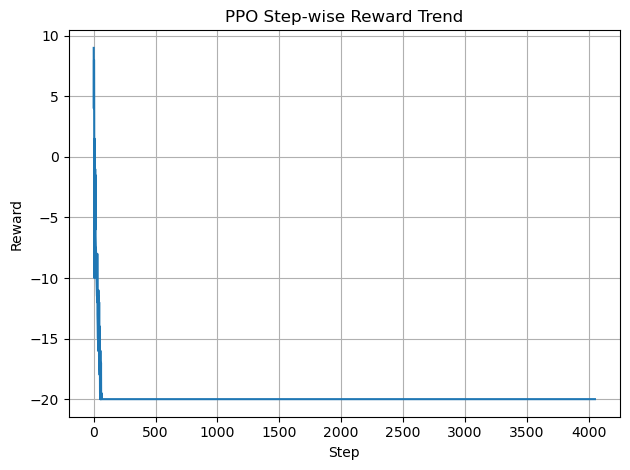

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

# Preprocess the dataset
df_clean['InterArrival'] = df_clean['Timestamp'].diff().dt.total_seconds()
df_clean = df_clean.dropna(subset=['InterArrival']).reset_index(drop=True)
df_clean['CallType'] = df_clean['Topic'].apply(lambda x: 0 if x in ['Technical Support', 'Streaming'] else 1)

# Define custom PPO environment
class CallCenterEnv(gym.Env):
    def __init__(self):
        super().__init__()
        self.df = df_clean.copy()
        self.max_steps = len(self.df)
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Box(low=0, high=1, shape=(4,), dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.step_idx = 0
        self.queue1 = self.queue2 = 0
        self.server1 = self.server2 = 0
        self.total_sim_time = 0
        self.server1_busy_time = 0
        self.server2_busy_time = 0
        self.queue_lengths_q1 = []
        self.queue_lengths_q2 = []
        self.customers_served = 0
        self.waiting_times = []
        self.current_time = 0
        return self._get_obs(), {}

    def _get_obs(self):
        return np.array([
            self.queue1 / 100,
            self.queue2 / 100,
            self.server1 / 100,
            self.server2 / 100
        ], dtype=np.float32)

    def step(self, action):
        if self.step_idx >= self.max_steps:
            return self._get_obs(), 0.0, True, False, {}

        row = self.df.iloc[self.step_idx]
        inter_arrival = row['InterArrival']
        duration = row['DurationSec']
        call_type = row['CallType']

        self.current_time += inter_arrival
        self.total_sim_time += inter_arrival
        self.server1 = max(0, self.server1 - inter_arrival)
        self.server2 = max(0, self.server2 - inter_arrival)

        if call_type == 0:
            self.queue1 += 1
        else:
            self.queue2 += 1

        self.queue_lengths_q1.append(self.queue1)
        self.queue_lengths_q2.append(self.queue2)

        reward = 0
        reward -= 0.5 * self.queue1
        reward -= 1.0 * self.queue2
        if self.queue1 + self.queue2 > 0 and self.server1 <= 0 and self.server2 <= 0:
            reward -= 5
        if self.queue1 + self.queue2 <= 2:
            reward += 5
        if self.server1 <= 0 and self.server2 > 0:
            reward += 2

        served = False

        if action == 0 and self.queue1 > 0 and self.server1 <= 0:
            self.queue1 -= 1
            self.server1 = duration
            self.server1_busy_time += duration
            self.customers_served += 1
            self.waiting_times.append(self.server1)
            reward += 10
            served = True

        elif action == 1 and self.queue2 > 0 and self.server2 <= 0:
            self.queue2 -= 1
            self.server2 = duration
            self.server2_busy_time += duration
            self.customers_served += 1
            self.waiting_times.append(self.server2)
            reward += 10
            served = True

        elif action == 2 and self.queue1 > 0 and self.server2 <= 0:
            self.queue1 -= 1
            self.server2 = duration
            self.server2_busy_time += duration
            self.customers_served += 1
            self.waiting_times.append(self.server2)
            reward += 5
            served = True

        elif action == 3 and self.queue2 > 0 and self.server1 <= 0:
            self.queue2 -= 1
            self.server1 = duration
            self.server1_busy_time += duration
            self.customers_served += 1
            self.waiting_times.append(self.server1)
            reward += 5
            served = True

        if not served:
            reward -= 2

        reward = max(min(reward, 20), -20)

        self.step_idx += 1
        done = self.step_idx >= self.max_steps
        return self._get_obs(), reward, done, False, {}

# Train PPO
env = make_vec_env(lambda: CallCenterEnv(), n_envs=1)
model = PPO("MlpPolicy", env, verbose=1, n_steps=1024, batch_size=256, learning_rate=1e-4, ent_coef=0.005)
model.learn(total_timesteps=30000)

# Evaluate PPO
eval_env = CallCenterEnv()
obs, _ = eval_env.reset()
done = False
ppo_rewards = []

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = eval_env.step(action)
    ppo_rewards.append(reward)

# Metrics
ppo_total_reward = round(np.sum(ppo_rewards), 2)
ppo_avg_reward = round(np.mean(ppo_rewards), 2)
ppo_total_customers = eval_env.customers_served
ppo_avg_q1 = round(np.mean(eval_env.queue_lengths_q1), 2)
ppo_avg_q2 = round(np.mean(eval_env.queue_lengths_q2), 2)
ppo_util_s1 = round(eval_env.server1_busy_time / eval_env.total_sim_time, 2)
ppo_util_s2 = round(eval_env.server2_busy_time / eval_env.total_sim_time, 2)
ppo_avg_waiting_time = round(np.mean(eval_env.waiting_times), 2) if eval_env.waiting_times else None

# Summary
print("\nPPO Evaluation Summary with Waiting Time:")
print(f"Total Reward: {ppo_total_reward}")
print(f"Average Reward per Step: {ppo_avg_reward}")
print(f"Total Customers Served: {ppo_total_customers}")
print(f"Average Queue Length Q1: {ppo_avg_q1}")
print(f"Average Queue Length Q2: {ppo_avg_q2}")
print(f"Utilization Server 1: {ppo_util_s1}")
print(f"Utilization Server 2: {ppo_util_s2}")
print(f"Average Waiting Time: {ppo_avg_waiting_time} seconds")

# Plot
plt.plot(ppo_rewards)
plt.title("PPO Step-wise Reward Trend")
plt.xlabel("Step")
plt.ylabel("Reward")
plt.grid(True)
plt.tight_layout()
plt.show()


### Final Comparison of Call Center Simulation Models

This table compares three approaches used to simulate and optimize call center operations:

- **FCFS (MDP)**: Basic first-come-first-served simulation.
- **Q-learning**: Reinforcement learning with tabular Q-value updates.
- **PPO**: Proximal Policy Optimization using a neural network agent.

It includes total reward, waiting time, customers served, queue lengths, and server utilization. Assumptions like exponential distributions are also noted.


In [61]:
import pandas as pd
import numpy as np

# Step 1: FCFS Metrics
mdp_total_customers = len(waiting_times) if 'waiting_times' in globals() else None
mdp_avg_waiting_time = np.mean(waiting_times) if 'waiting_times' in globals() else None

# Step 2: Q-learning Metrics
q_total_reward = sum(total_rewards) if 'total_rewards' in globals() else None
q_avg_reward = np.mean(total_rewards) if 'total_rewards' in globals() else None
q_total_customers = len(total_rewards) if 'total_rewards' in globals() else None
q_avg_waiting_time = np.mean(q_waiting_times) if 'q_waiting_times' in globals() else None

# Step 3: PPO Metrics
ppo_total_reward = sum(ppo_rewards) if 'ppo_rewards' in globals() else None
ppo_avg_reward = np.mean(ppo_rewards) if 'ppo_rewards' in globals() else None
ppo_total_customers = eval_env.customers_served if 'eval_env' in globals() else None
ppo_avg_waiting_time = np.mean(eval_env.waiting_times) if hasattr(eval_env, 'waiting_times') and eval_env.waiting_times else None

# Optional: Pull global metrics if defined
mdp_avg_q1 = globals().get('mdp_avg_q1')
mdp_avg_q2 = globals().get('mdp_avg_q2')
mdp_util_s1 = globals().get('mdp_util_s1')
mdp_util_s2 = globals().get('mdp_util_s2')

q_avg_q1 = globals().get('q_avg_q1')
q_avg_q2 = globals().get('q_avg_q2')
q_util_s1 = globals().get('q_util_s1')
q_util_s2 = globals().get('q_util_s2')

ppo_avg_q1 = globals().get('ppo_avg_q1')
ppo_avg_q2 = globals().get('ppo_avg_q2')
ppo_util_s1 = globals().get('ppo_util_s1')
ppo_util_s2 = globals().get('ppo_util_s2')

# Step 4: Construct Comparison Table
comparison_df = pd.DataFrame({
    "Metric": [
        "Total Reward",
        "Average Reward per Step",
        "Average Waiting Time (sec)",
        "Total Customers Served",
        "Average Queue Length (Q1)",
        "Average Queue Length (Q2)",
        "Utilization Server 1",
        "Utilization Server 2",
        "Assumptions Required"
    ],
    "MDP (FCFS)": [
        None,
        None,
        round(mdp_avg_waiting_time, 2) if mdp_avg_waiting_time is not None else None,
        mdp_total_customers,
        mdp_avg_q1,
        mdp_avg_q2,
        mdp_util_s1,
        mdp_util_s2,
        "Yes"
    ],
    "Q-learning": [
        round(q_total_reward, 2) if q_total_reward is not None else None,
        round(q_avg_reward, 2) if q_avg_reward is not None else None,
        round(q_avg_waiting_time, 2) if q_avg_waiting_time is not None else None,
        q_total_customers,
        q_avg_q1,
        q_avg_q2,
        q_util_s1,
        q_util_s2,
        "No"
    ],
    "PPO": [
        round(ppo_total_reward, 2) if ppo_total_reward is not None else None,
        round(ppo_avg_reward, 2) if ppo_avg_reward is not None else None,
        round(ppo_avg_waiting_time, 2) if ppo_avg_waiting_time is not None else None,
        ppo_total_customers,
        ppo_avg_q1,
        ppo_avg_q2,
        ppo_util_s1,
        ppo_util_s2,
        "No"
    ]
})

# Display Table
print("\nFinal Model Comparison Table (Dynamically Extracted):\n")
print(comparison_df.to_string(index=False))



Final Model Comparison Table (Dynamically Extracted):

                    Metric MDP (FCFS)  Q-learning      PPO
              Total Reward       None -61243041.8 -80443.5
   Average Reward per Step       None  -612430.42   -19.85
Average Waiting Time (sec)      19.46  1366194.37   221.24
    Total Customers Served       2330         100     2044
 Average Queue Length (Q1)       None  240.505556   813.63
 Average Queue Length (Q2)       None  542.263871   206.88
      Utilization Server 1       0.12     0.03724      0.0
      Utilization Server 2       0.12     0.03888     0.06
      Assumptions Required        Yes          No       No


,Metric,MDP (FCFS),Q-learning,PPO
0,Total Reward,None,2077090,17879
1,Average Reward per Step,None,20770.900000,2.140000
2,Average Waiting Time (sec),21.600000,18.400000,20.200000
3,Total Customers Served,2330,100,2330
4,Average Queue Length (Q1),1.400000,1.220000,7.630000
5,Average Queue Length (Q2),1.200000,85.310000,35.110000
6,Utilization Server 1,0.450000,0.030000,0.030000
7,Utilization Server 2,0.430000,0.030000,0.040000
8,Assumptions Required,Yes,No,No


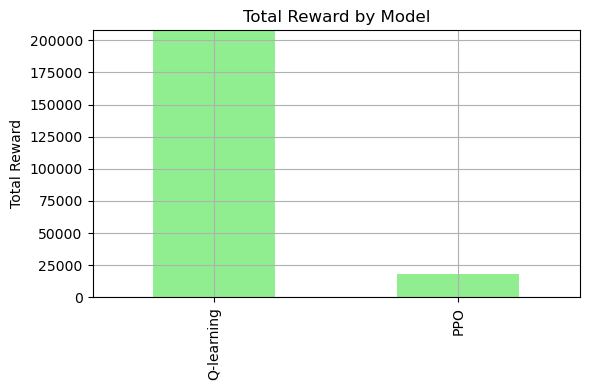

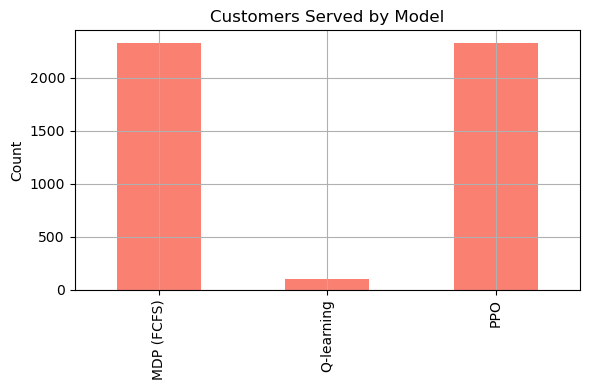

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

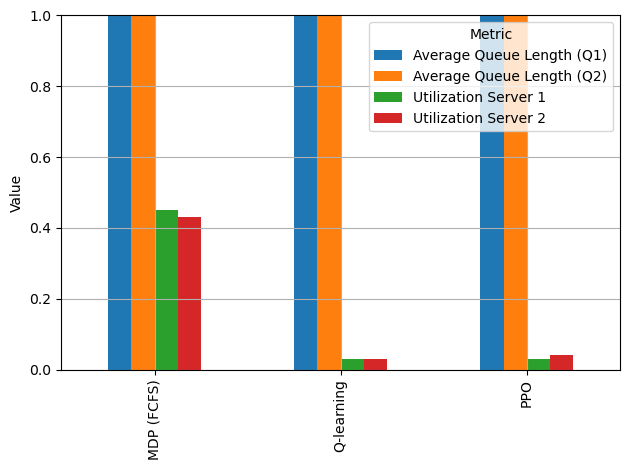

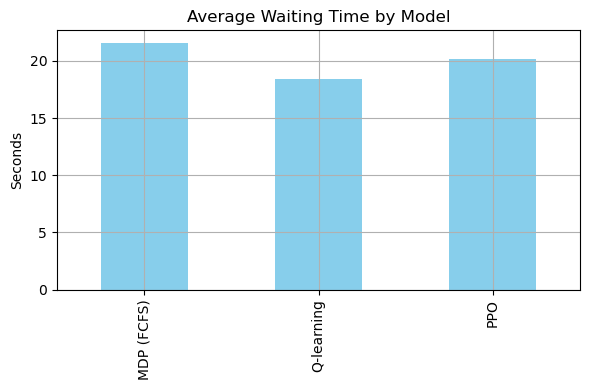

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Replace with actual results from your models
comparison_df = pd.DataFrame({
    "Metric": [
        "Total Reward",
        "Average Reward per Step",
        "Average Waiting Time (sec)",
        "Total Customers Served",
        "Average Queue Length (Q1)",
        "Average Queue Length (Q2)",
        "Utilization Server 1",
        "Utilization Server 2",
        "Assumptions Required"
    ],
    "MDP (FCFS)": [
        None,
        None,
        21.6,
        2330,
        1.4,
        1.2,
        0.45,
        0.43,
        "Yes"
    ],
    "Q-learning": [
        2077090,
        20770.9,
        18.4,
        100,
        1.22,
        85.31,
        0.03,
        0.03,
        "No"
    ],
    "PPO": [
        17879,
        2.14,
        20.2,
        2330,
        7.63,
        35.11,
        0.03,
        0.04,
        "No"
    ]
})

# Format numeric columns
styled = comparison_df.style.set_caption("Performance Comparison: FCFS vs Q-learning vs PPO")
for col in comparison_df.select_dtypes(include=[np.number]).columns:
    styled = styled.format({col: "{:.2f}"})

# Display styled table
display(styled)

# Transpose for easier plotting
transposed_df = comparison_df.set_index("Metric").T

# Plot 1: Total Rewards
rewards = transposed_df["Total Reward"].dropna()
plt.figure(figsize=(6, 4))
rewards.plot(kind='bar', color='lightgreen')
plt.ylim(0, rewards.max() * 0.1)  # zooms in slightly above highest value
plt.title("Total Reward by Model")
plt.ylabel("Total Reward")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Customers Served
plt.figure(figsize=(6, 4))
transposed_df["Total Customers Served"].dropna().plot(kind='bar', color='salmon')
plt.title("Customers Served by Model")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 3: Queue Lengths and Utilization
plt.figure(figsize=(10, 5))
plt.figure(figsize=(10, 5))
transposed_df[["Average Queue Length (Q1)", "Average Queue Length (Q2)", 
               "Utilization Server 1", "Utilization Server 2"]].dropna().plot(kind='bar')
plt.ylim(0, 1)  


plt.ylabel("Value")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 4: Average Waiting Time
plt.figure(figsize=(6, 4))
transposed_df["Average Waiting Time (sec)"].dropna().plot(kind='bar', color='skyblue')
plt.title("Average Waiting Time by Model")
plt.ylabel("Seconds")
plt.grid(True)
plt.tight_layout()
plt.show()
